# Spike Investigation: Anomaly Detection + Attribution

Companion notebook to `design_proposal.md`. This notebook generates the synthetic dataset,
runs the anomaly detector, trains the attribution model, and inspects results end to end.

For a single-command, non-interactive run that writes all outputs (CSVs, plots, narratives) to
`output/`, use `python run_pipeline.py` instead - this notebook re-runs the same code paths but
narrates and visualizes each step for review.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_generator import generate_dataset, CAUSE_TYPES
from anomaly_detection import build_scores, detect
from attribution import (
    build_feature_table, build_training_set, train_and_evaluate,
    predict_distribution, narrate, FEATURE_COLS,
)

pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

## 1. Synthetic data

See `design_proposal.md` -> *Data strategy* for the generative design. Quick shape check:

In [2]:
data = generate_dataset()
panel, events, labels = data["panel"], data["events"], data["labels"]
print("panel:", panel.shape, " events:", events.shape, " labeled anomaly-months:", labels.shape)
panel.head()

panel: (1752, 14)  events: (62, 8)  labeled anomaly-months: (312, 10)


,brand,channel,month,month_idx,spend,revenue,roas,iroas,mas,rroi,ctr,cpc,picr,impression_share
0,Aster Wellness,audio,2023-01,0,35548.091960,75967.097605,2.137023,1.217002,41040.861028,1.154517,0.004241,0.959805,0.045761,0.434085
1,Aster Wellness,audio,2023-02,1,36204.592489,73286.205692,2.024224,1.294102,46718.502782,1.249637,0.004990,0.782088,0.051093,0.397009
2,Aster Wellness,audio,2023-03,2,31881.573866,71043.043109,2.228342,1.231030,37301.381209,1.190983,0.005188,0.843545,0.057369,0.464133
3,Aster Wellness,audio,2023-04,3,23087.655695,51157.677873,2.215802,1.246139,32231.751469,1.329716,NaN,0.813361,0.042498,0.447637
4,Aster Wellness,audio,2023-05,4,44370.769216,104564.519554,2.356608,1.153823,44158.640654,1.110343,0.005807,0.829109,0.058149,0.494807


In [3]:
panel[["spend", "revenue", "roas", "iroas", "mas", "rroi", "ctr", "cpc", "picr"]].describe().T

,count,mean,std,min,25%,50%,75%,max
spend,1695.0,62190.154410,45729.537230,4065.192733,29656.454130,47325.290393,85996.930034,2.975820e+05
revenue,1695.0,191857.430035,151897.355457,18105.368722,89578.528853,134456.811049,260401.374324,1.098505e+06
roas,1695.0,3.247639,1.163591,1.115918,2.364334,3.092327,3.921771,9.267929e+00
iroas,1695.0,2.314781,0.819712,0.787433,1.647624,2.238747,2.858129,6.303368e+00
mas,1695.0,143724.083321,129391.567250,8636.682647,63617.109337,92882.223156,183282.840176,1.088259e+06
rroi,1695.0,2.312941,0.804404,0.797503,1.658715,2.242146,2.868517,5.591612e+00
ctr,1723.0,0.018062,0.014561,0.002534,0.006271,0.011912,0.027341,7.094362e-02
cpc,1582.0,1.178153,0.396396,0.427348,0.877117,1.107022,1.421651,2.776931e+00
picr,1709.0,0.101266,0.046346,0.034364,0.059654,0.091747,0.138789,3.455685e-01


A sample of injected ground-truth events (used only for evaluation, never as a model feature):

In [4]:
events.sample(8, random_state=1).sort_values("start_month")

,event_id,brand,channels,scope,start_month,end_month,shape,causes
2,2,Solstice Foods,"tv,paid_search,social,display,digital_video,re...",brand_wide,2023-07,2023-09,gradual,external_demand_spike:1.00
24,0,Crestline Beverages,audio,channel,2023-12,2023-12,sudden,spend_reduction_artifact:1.00
21,6,Verdant Snacks,digital_video,channel,2024-03,2024-03,sudden,survivorship_bias:1.00
38,0,Ridgeway Grocery,affiliate,channel,2024-08,2024-10,gradual,genuine_efficiency_gain:1.00
50,3,Aster Wellness,display,channel,2024-11,2025-01,gradual,genuine_efficiency_gain:1.00
41,3,Ridgeway Grocery,tv,channel,2025-02,2025-02,sudden,survivorship_bias:1.00
52,5,Aster Wellness,digital_video,channel,2025-07,2025-07,sudden,creative_refresh:1.00
60,7,Pinebrook Pet Co.,digital_video,channel,2025-11,2025-11,sudden,genuine_efficiency_gain:1.00


## 2. Anomaly detection

Baseline = own trailing robust trend + channel-level seasonal index, shrunk toward peer
(same-channel, other-brand) trend/variance for short-history brand-channels. Residuals are
turned into robust (MAD-based) z-scores; `sudden_z` catches 1-month step changes, `gradual_z`
catches slow 3-month ramps.

In [5]:
det = detect(panel, labels)
scored, sel = det["scored"], det["threshold_selection"]
print(f"chosen threshold={sel['best_threshold']:.2f}  precision={sel['precision']:.2f}  recall={sel['recall']:.2f}")
print(f"{scored['flagged'].sum()} of {len(scored)} brand-channel-months flagged")

chosen threshold=0.55  precision=0.36  recall=0.66
542 of 1752 brand-channel-months flagged


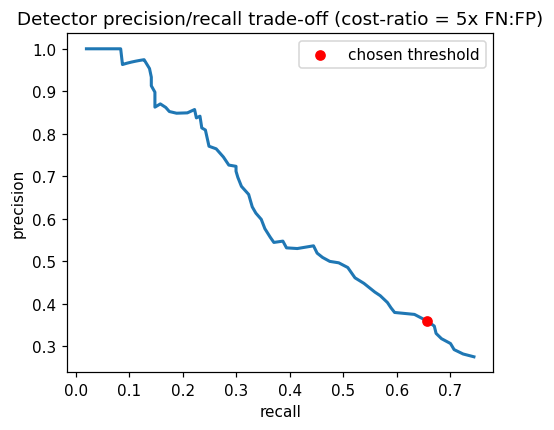

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(sel["curve"]["recall"], sel["curve"]["precision"], lw=2)
best_row = sel["curve"].iloc[(sel["curve"]["threshold"] - sel["best_threshold"]).abs().idxmin()]
ax.scatter([best_row["recall"]], [best_row["precision"]], color="red", zorder=5, label="chosen threshold")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.legend()
ax.set_title("Detector precision/recall trade-off (cost-ratio = 5x FN:FP)")
plt.show()

Example series - ROAS vs. the model's expected baseline, with flagged months marked:

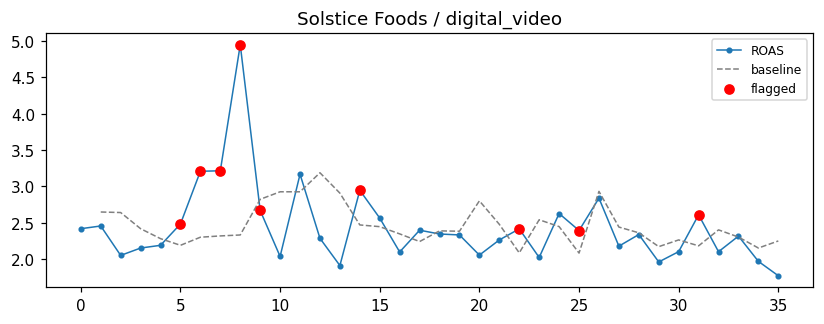

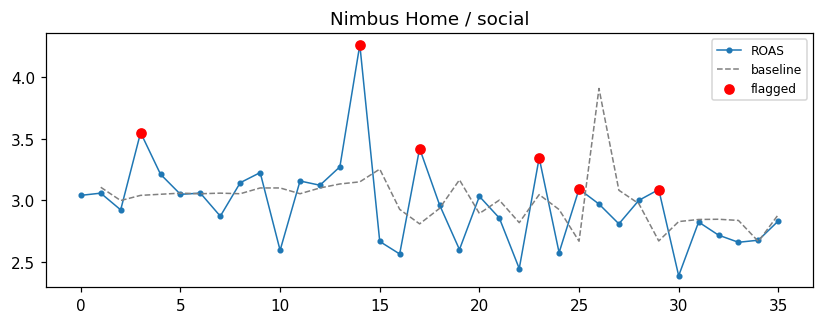

In [7]:
def plot_series(brand, channel):
    s = scored[(scored.brand == brand) & (scored.channel == channel)].sort_values("month_idx")
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(s["month_idx"], s["roas"], marker="o", ms=3, lw=1, label="ROAS")
    ax.plot(s["month_idx"], np.exp(s["baseline"]), lw=1, ls="--", color="gray", label="baseline")
    f = s[s["flagged"] == True]
    if len(f):
        ax.scatter(f["month_idx"], f["roas"], color="red", zorder=5, label="flagged")
    ax.set_title(f"{brand} / {channel}"); ax.legend(fontsize=8)
    plt.show()

plot_series("Solstice Foods", "digital_video")
plot_series("Nimbus Home", "social")

## 3. Attribution

Independent per-cause probabilistic classifiers (LightGBM, heavily regularized given the small
label set), trained on synthetic weak labels and evaluated out-of-fold against the injected
ground truth. Probabilities are *not* forced to sum to 1 across causes - real spikes are
multi-causal, and forcing a softmax would hide that.

Cross-validation is **grouped by event**, not by row: one event spans several months and channels,
so row-wise CV would leak the same shock into train and test (it inflated PR-AUC by up to 0.47).
The `lift_over_base` column is the honest cross-cause read - PR-AUC alone is not comparable
across causes with different prevalence, and lift <= 1 means the model learned nothing.

In [8]:
feat = build_feature_table(panel, scored)
rng = np.random.default_rng(3)
train = build_training_set(feat, labels, panel, rng)
result = train_and_evaluate(train)
result["metrics"]

,cause,n_pos,n_pos_events,pr_auc,base_rate,lift_over_base,brier,note
0,genuine_efficiency_gain,41,14,0.627486,0.075646,8.295058,0.044759,
1,spend_reduction_artifact,56,12,0.302826,0.103321,2.930925,0.089339,
2,mix_shift_artifact,60,8,0.098163,0.110701,0.886738,0.111183,WEAK: at/near chance
3,survivorship_bias,28,12,0.918885,0.051661,17.786983,0.010567,
4,external_demand_spike,53,7,0.355492,0.097786,3.635408,0.079813,
5,creative_refresh,27,13,0.589905,0.049815,11.841799,0.030361,


top-1 cause hit rate (OOF, event-grouped): 0.61


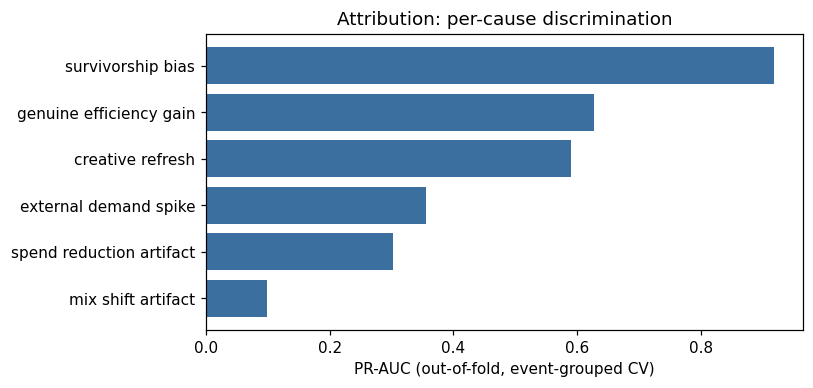

In [9]:
print(f"top-1 cause hit rate (OOF, event-grouped): {result['top1_hit_rate']:.2f}")

m = result["metrics"].dropna(subset=["pr_auc"]).sort_values("pr_auc")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(m["cause"].str.replace("_", " "), m["pr_auc"], color="#3b6fa0")
ax.set_xlabel("PR-AUC (out-of-fold, event-grouped CV)"); ax.set_title("Attribution: per-cause discrimination")
plt.show()

### Analyst-facing narrative

Example output for a handful of flagged anomalies - this is the format proposed for the analyst review UI (see `design_proposal.md` -> *Explainability*):

In [10]:
flagged = scored[scored["flagged"] == True].merge(
    feat, on=["brand", "channel", "month", "month_idx"], how="left", suffixes=("", "_f")
)
for _, row in flagged.sample(3, random_state=7).iterrows():
    dist = predict_distribution(result["models"], row)
    print(narrate(row, dist))
    print()

Crestline Beverages / social / 2024-12: ROAS moved +0.9 robust std. devs vs. expected (sudden, single-month pattern).
  No cause clears a confident threshold. Treat this as 'flagged, unexplained' - the driver may sit outside the six-cause taxonomy (competitor action, macro shift, a reporting change). Worth an analyst's eyes before it goes in the monthly narrative.
  Closest match was spend reduction artifact at 8%, below the 25% confidence bar.

Aster Wellness / social / 2024-04: ROAS moved +3.6 robust std. devs vs. expected (sudden, single-month pattern).
  Most likely drivers -
  - external demand spike (98% likely, 96% of the explained signal): other channels/brands moved similarly in the same month - a category-wide demand shift is a plausible shared driver
  - mix shift artifact (3% likely, 3% of the explained signal): this channel's share of the brand's total budget moved sharply - the metric change may reflect reallocation, not improvement

Ridgeway Grocery / affiliate / 2024-09

## 4. Limits of this notebook run

- Evaluated against *this run's* synthetic ground truth only - proves the method can recover the
  mechanisms we built into the simulator, not that the simulator matches reality.
- Per-cause attribution quality tracks how many injected examples of that cause exist in this
  run (see `n_pos` above); rarer causes have noisier out-of-fold estimates.
- Full discussion of production readiness, causal honesty, and where this breaks: `design_proposal.md`.